In [292]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

In [293]:
X, y = make_regression(n_samples=100, n_features=2, noise=20, random_state=42)
X = StandardScaler().fit_transform(X)

In [294]:
X

array([[-1.26257379e+00,  6.26382462e-01],
       [ 2.03953889e-01, -1.18427387e+00],
       [ 8.24417992e-01,  2.16977369e+00],
       [ 6.91065076e-01, -1.07512253e-01],
       [ 1.00235904e+00,  1.38195623e-01],
       [-9.08369955e-01, -8.55089945e-01],
       [-2.11638821e+00, -6.09106962e-02],
       [-3.88430263e-01,  8.27463953e-01],
       [ 1.08928090e+00,  1.33039737e+00],
       [ 1.47694392e+00,  7.22351933e-01],
       [-1.16284792e+00, -1.23783954e+00],
       [ 8.69968816e-01, -8.96693004e-01],
       [-5.69322234e-01, -3.27731058e-01],
       [-3.24574083e-01, -1.50680152e+00],
       [-1.39185696e-01, -2.69818200e-01],
       [-8.58229504e-01, -1.55845135e+00],
       [ 1.21002476e+00,  2.96552072e-01],
       [ 5.16006392e-01, -4.21697320e-01],
       [ 2.49573464e-01,  9.40404540e-01],
       [ 5.11186215e-02,  9.75508276e-01],
       [-4.08268674e-01, -5.02843704e-01],
       [-1.11116931e+00,  4.42289427e-01],
       [ 1.98912620e+00,  7.37949528e-01],
       [ 1.

## Gradient Descient - All data

In [299]:
# Step 1: Initialize hyperparameters
eta = 0.001
n_iter = 20
random_state = 42
m = X.shape[0]

# Step 2: initalize weights (to small random numbers)
rgn = np.random.RandomState(random_state)
w_ = rgn.normal(loc=0.0, scale=0.01, size = 1 + X.shape[1])
cost_ = []

def fit(X, y):
    for iter_ in range(n_iter):
        net_input = np.dot(X, w_[1:]) + w_[0]
        errors = y - net_input
        w_[1:] += eta * np.dot(X.T, errors)
        w_[0] += eta * errors.sum()

        cost = (errors ** 2).sum() / 2 / m
        cost_.append(cost)
    return cost_

def predict(X):
    net_input = np.dot

In [300]:
X.shape

(100, 2)

In [301]:
w_[1:].shape

(2,)

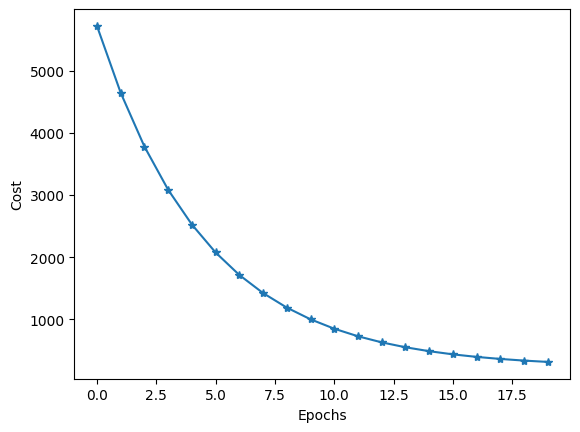

In [303]:
cost = fit(X,y)

plt.plot(np.arange(len(cost)), cost, marker='*')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.show()

## Stochastic Gradient Descient - Individual Sample

In [322]:
# Step 1: initalize hyperparameters
eta = 0.001
n_iter = 20
random_state = 1

# Step 2: initalize weights (to small random numbers)
rgen = np.random.RandomState(random_state)
w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])

# Step 3: initialize cost lists
cost_ = []


# Step 4: compute net input, linear activation function, update weights, track cost
def fit(X, y):
    for iter_ in range(n_iter):
        cost = []
        # shuffle the data after each iteration to avoid repetitive cycles when we optimize the cost function
        shuffle = np.random.permutation(np.arange(X.shape[0]))
        X, y = X[shuffle], y[shuffle]
        
        # process one sample at a time (this is what makes it SGD)
        for idx, (xi, target) in enumerate(zip(X, y)):
            # make prediction for this single sample
            net_input = np.dot(xi, w_[1:]) + w_[0]
            prediction = net_input  # Linear activation
            
            # compute error for this sample
            error = target - prediction
            
            # update weights using this single sample
            w_[1:] += eta * error * xi
            w_[0] += eta * error
            
            # track cost for this sample
            cost.append(error**2 / 2.0)
        
        # average cost for this epoch
        avg_cost = sum(cost) / len(y)
        cost_.append(avg_cost)
    
    return cost_

# Step 5: compute the threshold (linear) function; it's just the net input function in the linear model
def predict(X):
    net_input = np.dot(X, w_[1:]) + w_[0]
    # threshold function
    y_pred = net_input
    
    return y_pred

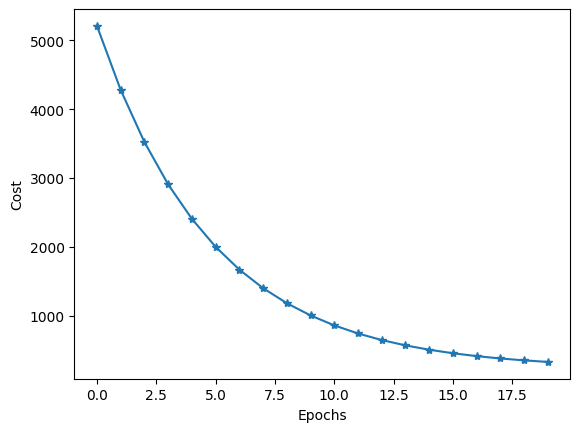

In [324]:
cost = fit(X,y)

plt.plot(np.arange(len(cost)), cost, marker='*')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.show()

## Batch Stochastic Gradient Descient - Multiple Samples